# Comparing the results of multiple cryptocurrencies


## Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import random

In [2]:
from os import listdir
from os.path import isfile, join


Importing the collected data

In [3]:
#from google.colab import files
#uploaded = files.upload()
#%ls

In [4]:
def plot_time_series(predicted, true, n_training, filename):
  """
  Plot the time series
  """
  plt.figure(figsize=(16,10)) #plotting
  plt.axvline(x=n_training, color="#ffd166", linestyle='-') #size of the training set

  plt.plot(predicted, label='Predicted Price', color="#118ab2") #predicted plot
  plt.plot(true, label='True Price', color="#06d6a0") #actual plot

  plt.title('Time-Series Prediction', fontsize=16)
  plt.xlabel('Time', fontsize=14)
  plt.ylabel('Price', fontsize=14)

  plt.xlim(0)
  plt.legend()
  plt.show()
  #plt.savefig(filename) 

## LSTM Model


### Model Definition

In [5]:
class LSTMCustom(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTMCustom, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.seq_length = seq_length #sequence length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm

        #self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        #self.fc = nn.Linear(128, num_classes) #fully connected last layer

        #self.relu = nn.ReLU()

        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state

        #hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        #out = self.relu(hn)
        #out = self.fc_1(out) #first Dense
        #out = self.relu(out) #relu
        #out = self.fc(out) #Final Output
        
        out = self.fc(output[:,-1,:])
        return out

Model Parameters

In [6]:
num_epochs = 100 #until loss stops dropping
learning_rate = 0.01 #0.001 lr (.001-0.03)

#this needs to change with x, df_x_ss to change input
input_size = 7 #number of features
hidden_size = 64 #number of features in hidden state (try 16-256)
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

look_back = 12 #sliding window, how many of the previous feature vectors are included in the input


In [7]:
criterion = torch.nn.MSELoss()  # mean-squared error for regression

### Training Each Crypto

In [8]:
mm = MinMaxScaler()
ss = StandardScaler()

In [9]:
def train_test_split_tensor(x, y):
  """
  Custom train/test splitting
  TODO: maybe shorten code by using sklearn.preprocessing.train_test_split
  """
  cutoff = round(x.shape[0] * 0.8)

  # split into train and test
  x_train = x[:cutoff, :]
  x_test = x[cutoff:,:]
  y_train = y[:cutoff, :]
  y_test = y[cutoff:, :]

  # convert to tensor
  x_train = Variable(torch.Tensor(x_train))
  x_test = Variable(torch.Tensor(x_test))
  y_train = Variable(torch.Tensor(y_train))
  y_test = Variable(torch.Tensor(y_test)) 
  
  return x_train, x_test, y_train, y_test, cutoff

In [10]:
def process_data(df):

  # split into x and y

  #set this range to choose input parameters (do it in the main loop for df_x_ss as well)
  x = df.iloc[:, :-2]
  y = df.iloc[look_back:,-1:]
  y_mm = mm.fit_transform(y)
  x_raw = ss.fit_transform(x)

  x_2d = []
  for index in range(len(x_raw)):
    x_2d.append(x_raw[index - look_back:index+1])
  x_2d = np.array(x_2d[look_back:])

  # get train and test split and convert to tensors
  x_train, x_test, y_train, y_test, cutoff = train_test_split_tensor(x_2d, y_mm)

  return x_train, x_test, y_train, y_test, cutoff

In [11]:
def train(df, lstm):
  """
  Train the lstm
  """
  x_train, x_test, y_train, y_test, cutoff = process_data(df)

  for epoch in range(num_epochs):
    outputs = lstm.forward(x_train) #forward pass
    optimizer.zero_grad() #caluclate the gradient, manually setting to 0
  
    # obtain the loss function
    loss = criterion(outputs, y_train)
  
    loss.backward() #calculates the loss of the loss function
  
    optimizer.step() #improve from loss, i.e backprop
    if epoch % 10 == 0: 
      print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

  return lstm, cutoff

In [12]:
def classify(predict, direction):
    results = []
    #multiplication by 1+- small value if we want a neutral range, needs to be changed in split_lags to set the price direction feature as the same
    for i in range(len(predict)):
        if (predict[i] > predict[i-1]*1.0):
            results.append("positive")
        elif (predict[i] <= predict[i-1]*1.0):
            results.append("negative")
        else:
            results.append("neutral")
    results.append("neutral")
    totalcorrect = neutralcount = neutralcorrect = positivecorrect = negativecorrect = positivecount = negativecount = neutralprediction = 0
    for i in range(len(predict)):
        if results[i] == "neutral":
            neutralprediction += 1
        if direction[i] == "positive":
            positivecount += 1
        elif direction[i] == "negative":
            negativecount += 1
        elif direction[i] == "neutral":
            neutralcount += 1
        if results[i] == direction[i]:
            totalcorrect += 1
            if results[i] == "negative":
                negativecorrect += 1
            elif results[i] == "positive":
                positivecorrect += 1
            elif results[i] == "neutral":
                neutralcorrect += 1

    print("% positive: ", positivecount/len(predict))
    print("% negative: ", negativecount/len(predict))
    #print("% neutral: ", neutralcount/len(predict))
    print(f"positive correct: {positivecorrect}/{positivecount} ", positivecorrect/positivecount)
    print(f"negative correct: {negativecorrect}/{negativecount} ", negativecorrect/negativecount)
    #print("neutral correct: ", neutralcorrect/neutralcount)

    return totalcorrect/len(predict)

binance-coinhourly.csv
Epoch: 0, loss: 0.18289
Epoch: 10, loss: 0.00670
Epoch: 20, loss: 0.00147
Epoch: 30, loss: 0.00110
Epoch: 40, loss: 0.00044
Epoch: 50, loss: 0.00016
Epoch: 60, loss: 0.00015
Epoch: 70, loss: 0.00009
Epoch: 80, loss: 0.00009
Epoch: 90, loss: 0.00008
% positive:  0.5177838577291382
% negative:  0.48221614227086185
positive correct: 361/757  0.47688243064729197
negative correct: 359/705  0.5092198581560283
test accuracy: 0.49247606019151846


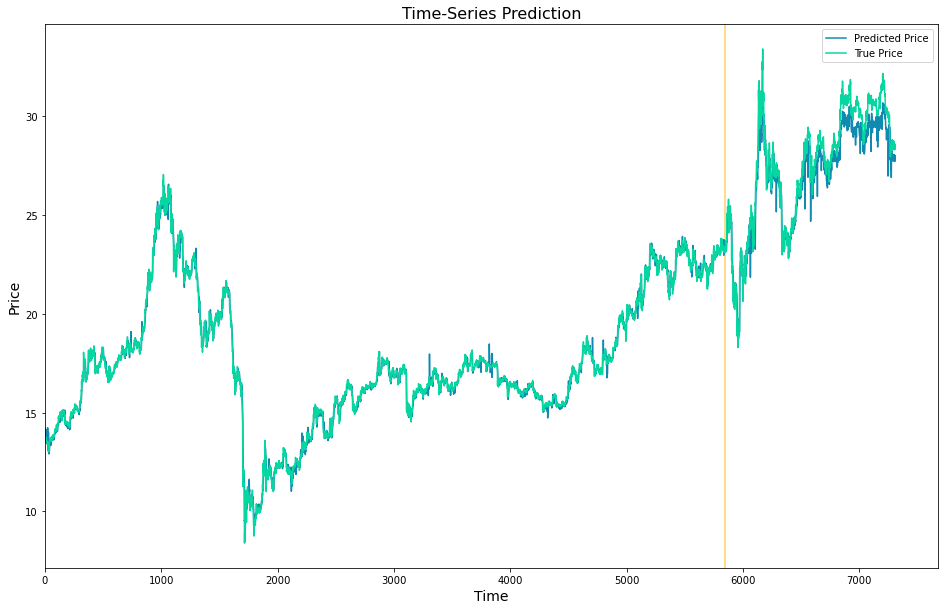

bitcoin-cashhourly.csv
Epoch: 0, loss: 0.16984
Epoch: 10, loss: 0.00411
Epoch: 20, loss: 0.00220
Epoch: 30, loss: 0.00057
Epoch: 40, loss: 0.00031
Epoch: 50, loss: 0.00020
Epoch: 60, loss: 0.00018
Epoch: 70, loss: 0.00014
Epoch: 80, loss: 0.00012
Epoch: 90, loss: 0.00011
% positive:  0.4993160054719562
% negative:  0.5006839945280438
positive correct: 335/730  0.4589041095890411
negative correct: 354/732  0.48360655737704916
test accuracy: 0.47127222982216144


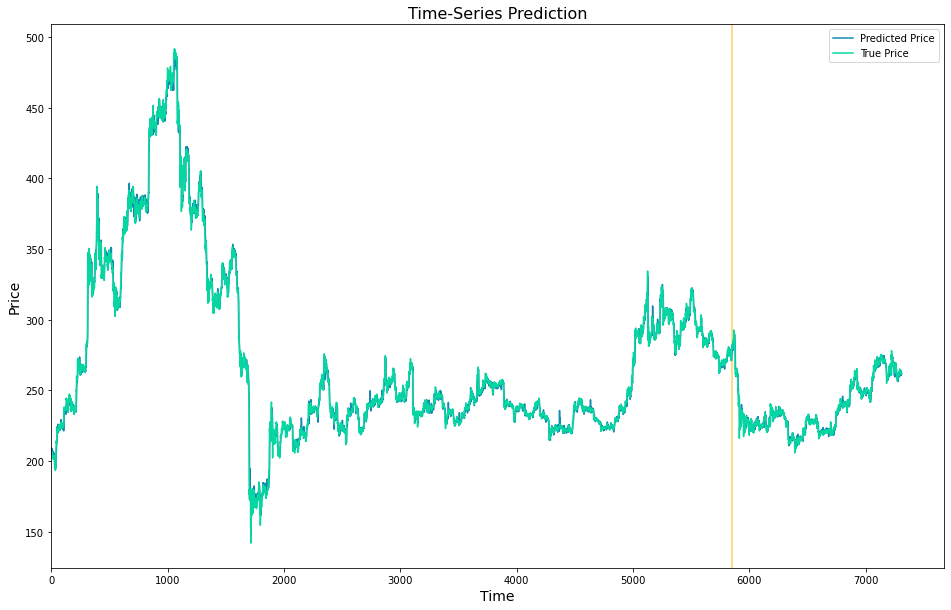

bitcoinhourly.csv
Epoch: 0, loss: 0.23404
Epoch: 10, loss: 0.01479
Epoch: 20, loss: 0.00268
Epoch: 30, loss: 0.00124
Epoch: 40, loss: 0.00072
Epoch: 50, loss: 0.00036
Epoch: 60, loss: 0.00022
Epoch: 70, loss: 0.00013
Epoch: 80, loss: 0.00010
Epoch: 90, loss: 0.00008
% positive:  0.5164158686730507
% negative:  0.4835841313269494
positive correct: 391/755  0.5178807947019868
negative correct: 322/707  0.45544554455445546
test accuracy: 0.48768809849521205


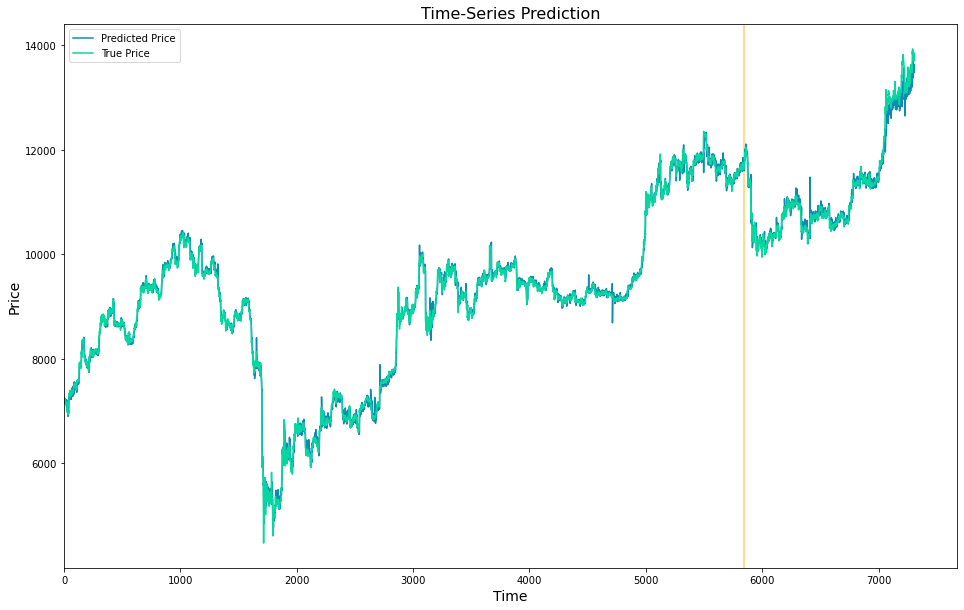

cardanohourly.csv
Epoch: 0, loss: 0.25819
Epoch: 10, loss: 0.00575
Epoch: 20, loss: 0.00260
Epoch: 30, loss: 0.00104
Epoch: 40, loss: 0.00034
Epoch: 50, loss: 0.00026
Epoch: 60, loss: 0.00015
Epoch: 70, loss: 0.00013
Epoch: 80, loss: 0.00010
Epoch: 90, loss: 0.00009
% positive:  0.49589603283173733
% negative:  0.5041039671682627
positive correct: 342/725  0.47172413793103446
negative correct: 362/737  0.49118046132971505
test accuracy: 0.48153214774281805


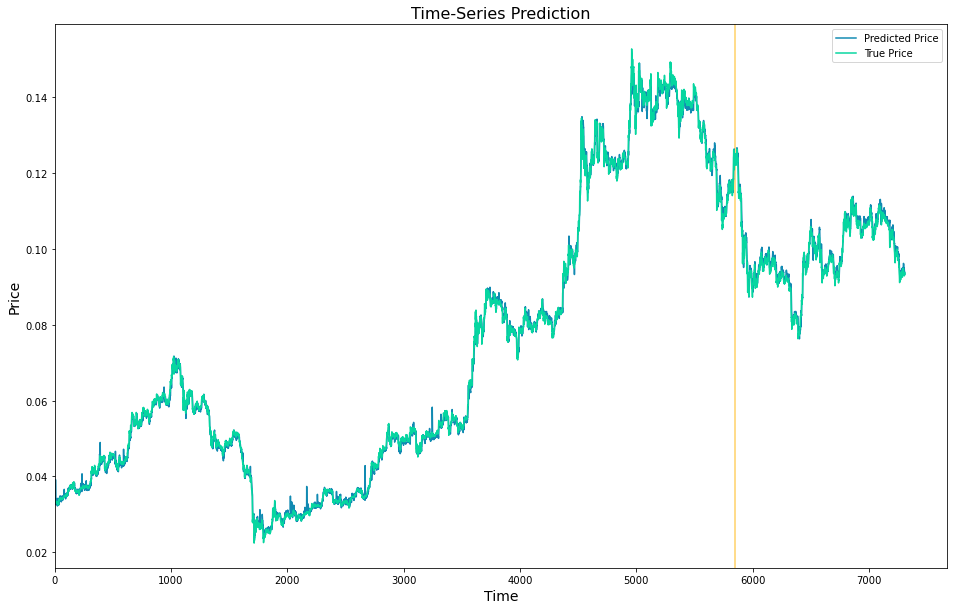

chainlinkhourly.csv
Epoch: 0, loss: 0.11326
Epoch: 10, loss: 0.00251
Epoch: 20, loss: 0.00188
Epoch: 30, loss: 0.00044
Epoch: 40, loss: 0.00020
Epoch: 50, loss: 0.00017
Epoch: 60, loss: 0.00011
Epoch: 70, loss: 0.00009
Epoch: 80, loss: 0.00008
Epoch: 90, loss: 0.00007
% positive:  0.4801641586867305
% negative:  0.5198358413132695
positive correct: 319/702  0.4544159544159544
negative correct: 380/760  0.5
test accuracy: 0.4781121751025992


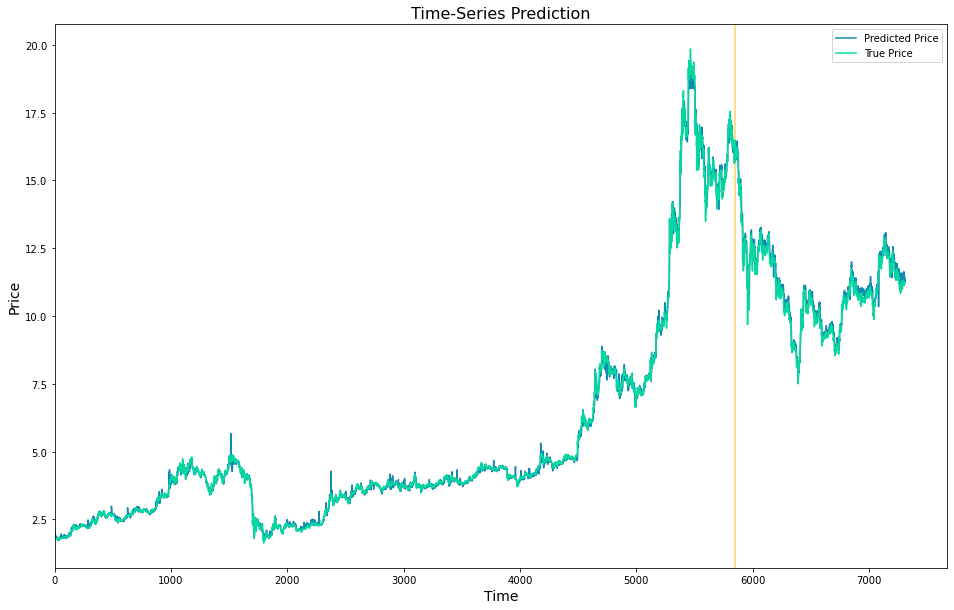

ethereumhourly.csv
Epoch: 0, loss: 0.16099
Epoch: 10, loss: 0.00280
Epoch: 20, loss: 0.00157
Epoch: 30, loss: 0.00038
Epoch: 40, loss: 0.00025
Epoch: 50, loss: 0.00009
Epoch: 60, loss: 0.00009
Epoch: 70, loss: 0.00007
Epoch: 80, loss: 0.00006
Epoch: 90, loss: 0.00005
% positive:  0.5143638850889193
% negative:  0.4856361149110807
positive correct: 393/752  0.5226063829787234
negative correct: 335/710  0.47183098591549294
test accuracy: 0.49794801641586867


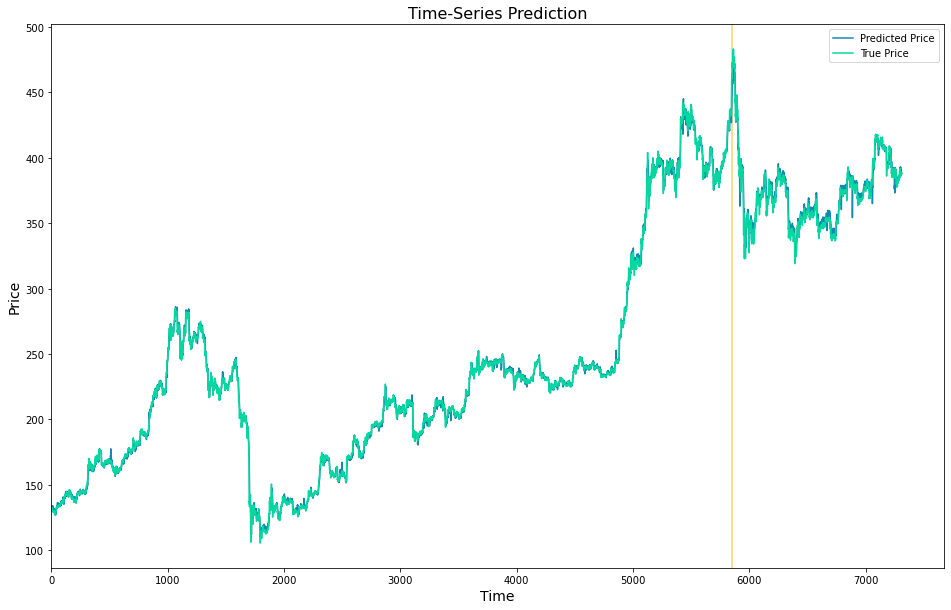

litecoinhourly.csv
Epoch: 0, loss: 0.11758
Epoch: 10, loss: 0.00519
Epoch: 20, loss: 0.00121
Epoch: 30, loss: 0.00071
Epoch: 40, loss: 0.00035
Epoch: 50, loss: 0.00019
Epoch: 60, loss: 0.00016
Epoch: 70, loss: 0.00014
Epoch: 80, loss: 0.00012
Epoch: 90, loss: 0.00011
% positive:  0.4849521203830369
% negative:  0.5150478796169631
positive correct: 362/709  0.5105782792665726
negative correct: 381/753  0.5059760956175299
test accuracy: 0.5082079343365253


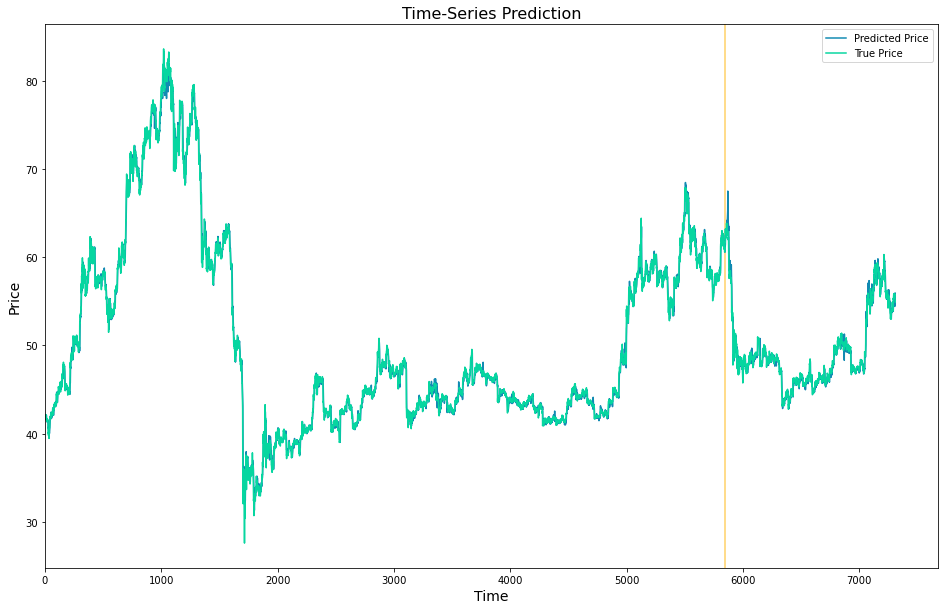

ripplehourly.csv
Epoch: 0, loss: 0.22609
Epoch: 10, loss: 0.00726
Epoch: 20, loss: 0.00312
Epoch: 30, loss: 0.00117
Epoch: 40, loss: 0.00059
Epoch: 50, loss: 0.00027
Epoch: 60, loss: 0.00023
Epoch: 70, loss: 0.00020
Epoch: 80, loss: 0.00017
Epoch: 90, loss: 0.00016
% positive:  0.4883720930232558
% negative:  0.5116279069767442
positive correct: 327/714  0.4579831932773109
negative correct: 330/748  0.4411764705882353
test accuracy: 0.4493844049247606


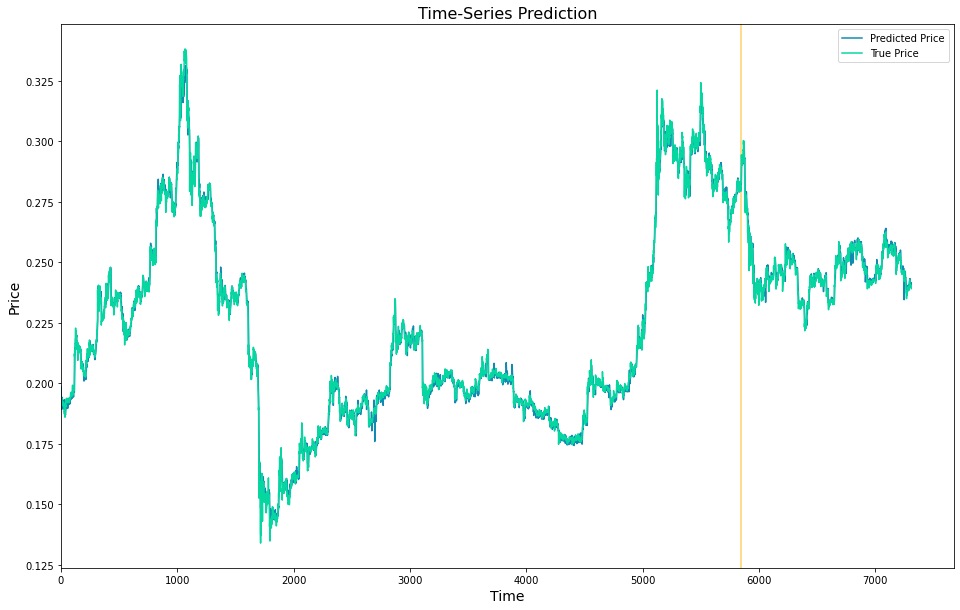

stellarhourly.csv
Epoch: 0, loss: 0.30107
Epoch: 10, loss: 0.00773
Epoch: 20, loss: 0.00260
Epoch: 30, loss: 0.00117
Epoch: 40, loss: 0.00066
Epoch: 50, loss: 0.00030
Epoch: 60, loss: 0.00019
Epoch: 70, loss: 0.00017
Epoch: 80, loss: 0.00014
Epoch: 90, loss: 0.00013
% positive:  0.5068399452804377
% negative:  0.49316005471956226
positive correct: 357/741  0.4817813765182186
negative correct: 347/721  0.4812760055478502
test accuracy: 0.48153214774281805


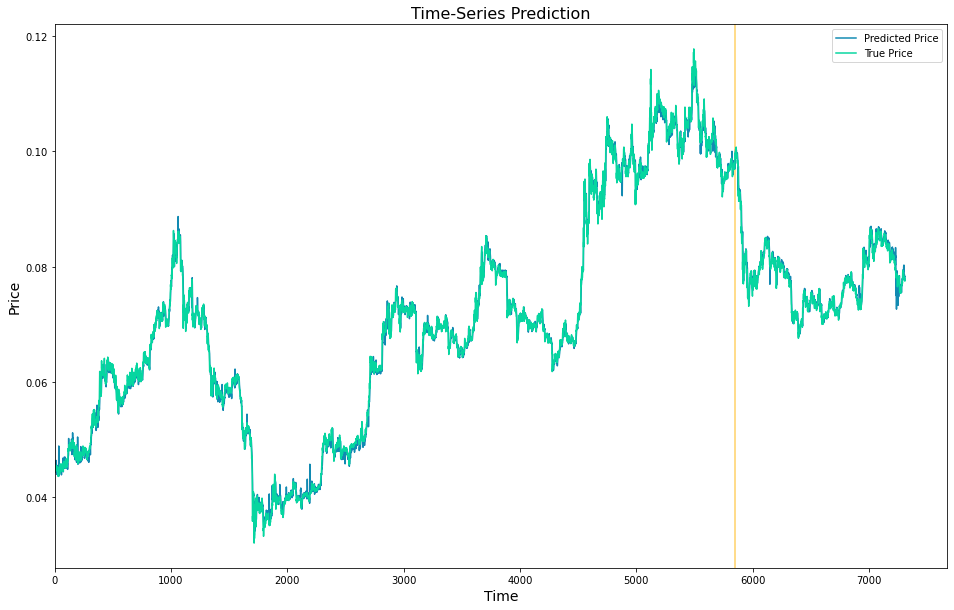

In [13]:

#current processed data in datatest and dataOriginaltest
dir_path = "datatest/"
file_list = [f for f in listdir(dir_path) if isfile(join(dir_path, f))]
#file_list = [f for f in listdir() if isfile(f)]

file_endings = ["5m.csv", "hourly.csv", "daily.csv", "2h.csv", "30m.csv", "5mJune.csv", "15min.csv"]

# FIXME: move to each fileending?
# im going to start with just 5m
file_ending = file_endings[1]
results = []
for filename in [name for name in file_list if file_ending in name]:
  crypto_name = filename.replace(file_ending, "")
  print(filename)
  
  df = pd.read_csv(dir_path + filename)
  #print(df.head())

  # define LSTM class
  lstm = LSTMCustom(num_classes, input_size, hidden_size, num_layers, df.shape[1]) 
  optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate) 

  lstm, cutoff = train(df, lstm)

  #set this range to choose input parameters
  df_x_ss = ss.transform(df.iloc[:, :-2]) #old transformers


  df_x_2d = []
  for index in range(len(df_x_ss)):
    df_x_2d.append(df_x_ss[index-look_back:index])
  
  df_x_2d = df_x_2d[look_back:]
  df_y_mm = mm.transform(df.iloc[look_back:, -1:]) #old transformers

  df_x_2d = np.array(df_x_2d)
  df_x_ss = Variable(torch.Tensor(df_x_2d)) #converting to Tensors
  df_y_mm = Variable(torch.Tensor(df_y_mm))

  train_predict = lstm(df_x_ss) #forward pass
  data_predict = train_predict.data.numpy() #numpy conversion
  
  dataY_plot = df_y_mm.data.numpy()

  data_predict = mm.inverse_transform(data_predict) #reverse transformation

  test_accuracy = classify(data_predict[cutoff:], df.iloc[cutoff+look_back:].priceDirection.reset_index(drop=True))
  print(f"test accuracy: {test_accuracy}")

  dataY_plot = mm.inverse_transform(dataY_plot)

  plot_name = f"{crypto_name}{file_ending}.png"
  plot_time_series(data_predict, dataY_plot, cutoff, plot_name)

  #model_name = f"{crypto_name}.pth"
  #torch.save(lstm.state_dict(), model_name)

  results.append([filename, test_accuracy])

In [14]:
resultsdf = pd.DataFrame(results)
print("input size: ", input_size)
print("epochs: ", num_epochs)
print("learning rate: ", learning_rate)
print("hidden size: ", hidden_size)
print("look back: ", look_back)
print(resultsdf)

input size:  7
epochs:  100
learning rate:  0.01
hidden size:  64
look back:  12
                        0         1
0  binance-coinhourly.csv  0.492476
1  bitcoin-cashhourly.csv  0.471272
2       bitcoinhourly.csv  0.487688
3       cardanohourly.csv  0.481532
4     chainlinkhourly.csv  0.478112
5      ethereumhourly.csv  0.497948
6      litecoinhourly.csv  0.508208
7        ripplehourly.csv  0.449384
8       stellarhourly.csv  0.481532
